# The Rise of Indie Games: Steam Market Analysis (2010-2023)

This notebook explores how indie games on Steam have changed over time in terms of release volume, player engagement, pricing, and genre patterns.

Main questions:
- How has indie game output changed over time?
- Do indie games offer strong value compared with non-indie games?
- What genre patterns appear in the indie market?


In [8]:
from pathlib import Path
import ast

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from PIL import Image

DATA_PATH = Path('.')
CSV_FILE = DATA_PATH / 'games_march2025_full.csv'

if not CSV_FILE.exists():
    raise FileNotFoundError('Place games_march2025_full.csv in the project folder before running this notebook.')

df = pd.read_csv(CSV_FILE)
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,488824,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,19.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,0,0,0,0,0,"{'FPS': 8082, 'Multiplayer': 6139, 'Tactical':...",84,1168404,76,13017


## Data cleaning

The dataset is cleaned to make date, genre, price, score, and playtime fields usable for analysis.

In [9]:
# Keep a copy of raw dimensions for context
raw_shape = df.shape
print('Raw shape:', raw_shape)

# Release year
if 'release_date' in df.columns:
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['release_year'] = df['release_date'].dt.year

# Parse genre strings safely
if 'genres' in df.columns:
    def parse_genres(x):
        if pd.isna(x):
            return []
        if isinstance(x, list):
            return x
        try:
            return ast.literal_eval(x)
        except Exception:
            return []

    df['genres'] = df['genres'].apply(parse_genres)
    df['is_indie'] = df['genres'].apply(lambda g: 'Indie' in g)

# Numeric conversion
for col in ['price', 'user_score', 'average_playtime_forever', 'num_reviews_total']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Boolean cleanup if present
for col in ['windows', 'mac', 'linux']:
    if col in df.columns:
        df[col] = df[col] == 'TRUE'

# Drop rows missing core fields
required = [c for c in ['release_date', 'genres', 'user_score'] if c in df.columns]
if required:
    df = df.dropna(subset=required)

# Filter out rows with no reviews or no playtime
if 'num_reviews_total' in df.columns:
    df = df[df['num_reviews_total'] > 0]
if 'average_playtime_forever' in df.columns:
    df = df[df['average_playtime_forever'] > 0]

print('Cleaned shape:', df.shape)

Raw shape: (94948, 47)
Cleaned shape: (7774, 49)


## Release trends

This section looks at how many indie games were released each year.

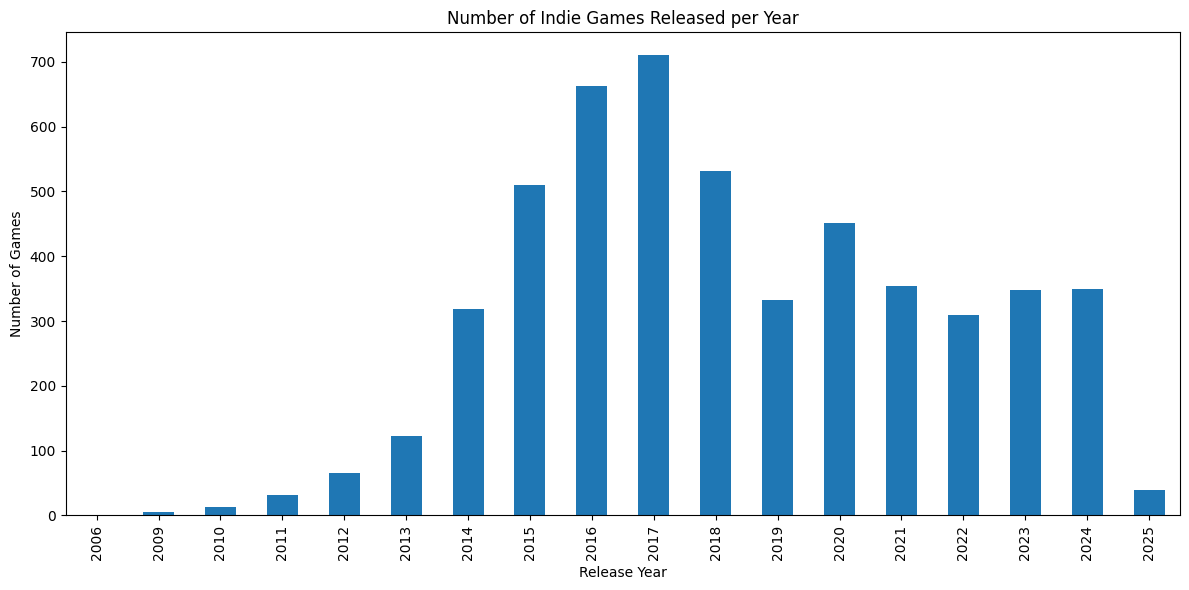

In [10]:
indie_games = df[df['is_indie']].copy()
indie_by_year = indie_games.groupby('release_year').size()

plt.figure(figsize=(12, 6))
indie_by_year.plot(kind='bar')
plt.title('Number of Indie Games Released per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()

## Engagement over time

Average user score and average playtime are used as simple indicators of player reception and engagement.

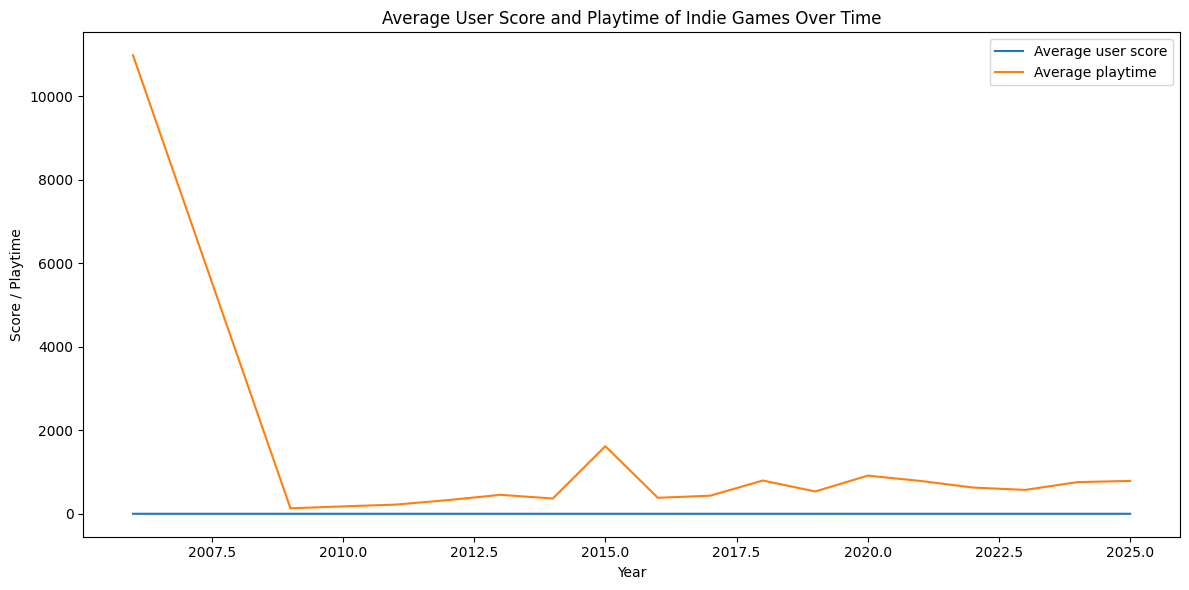

In [11]:
indie_yearly_metrics = indie_games.groupby('release_year')[['user_score', 'average_playtime_forever']].mean()

plt.figure(figsize=(12, 6))
plt.plot(indie_yearly_metrics.index, indie_yearly_metrics['user_score'], label='Average user score')
plt.plot(indie_yearly_metrics.index, indie_yearly_metrics['average_playtime_forever'], label='Average playtime')
plt.title('Average User Score and Playtime of Indie Games Over Time')
plt.xlabel('Year')
plt.ylabel('Score / Playtime')
plt.legend()
plt.tight_layout()
plt.show()

## Indie vs non-indie comparison

These plots compare scores and prices across indie and non-indie games.

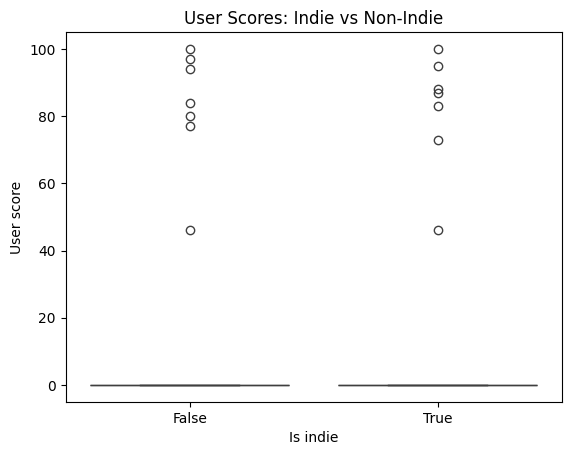

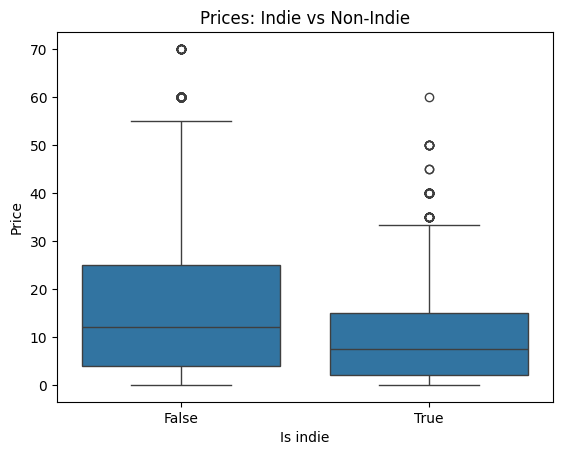

In [12]:
sns.boxplot(x='is_indie', y='user_score', data=df)
plt.title('User Scores: Indie vs Non-Indie')
plt.xlabel('Is indie')
plt.ylabel('User score')
plt.show()

sns.boxplot(x='is_indie', y='price', data=df)
plt.title('Prices: Indie vs Non-Indie')
plt.xlabel('Is indie')
plt.ylabel('Price')
plt.show()

## Trend model

A simple linear regression is used to estimate the long-run growth trend in indie releases.

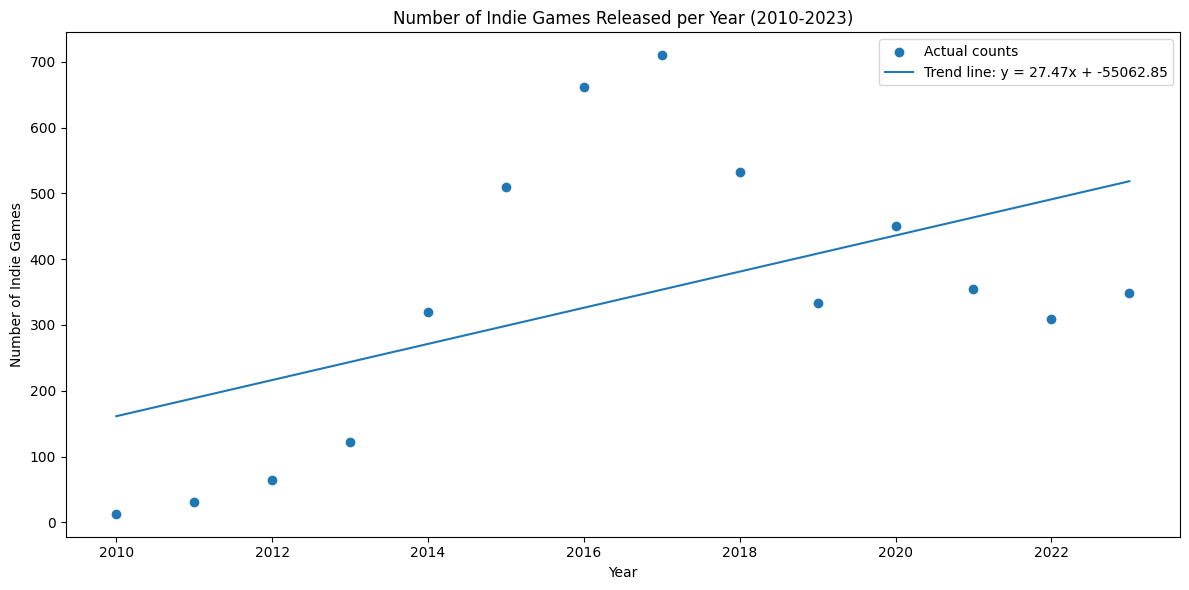

Trend slope: 27.47 games per year


In [13]:
indie_filtered = indie_games[(indie_games['release_year'] >= 2010) & (indie_games['release_year'] <= 2023)].copy()
indie_by_year_filtered = indie_filtered.groupby('release_year').size().reset_index(name='count')

x = indie_by_year_filtered['release_year'].values
y = indie_by_year_filtered['count'].values
m, b = np.polyfit(x, y, 1)

plt.figure(figsize=(12, 6))
plt.scatter(x, y, label='Actual counts')
plt.plot(x, m * x + b, label=f'Trend line: y = {m:.2f}x + {b:.2f}')
plt.title('Number of Indie Games Released per Year (2010-2023)')
plt.xlabel('Year')
plt.ylabel('Number of Indie Games')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Trend slope: {m:.2f} games per year')

## Outlier-aware engagement trends

To reduce distortion from extreme playtime values, the top 1 percent of playtime values are removed before recomputing yearly averages.

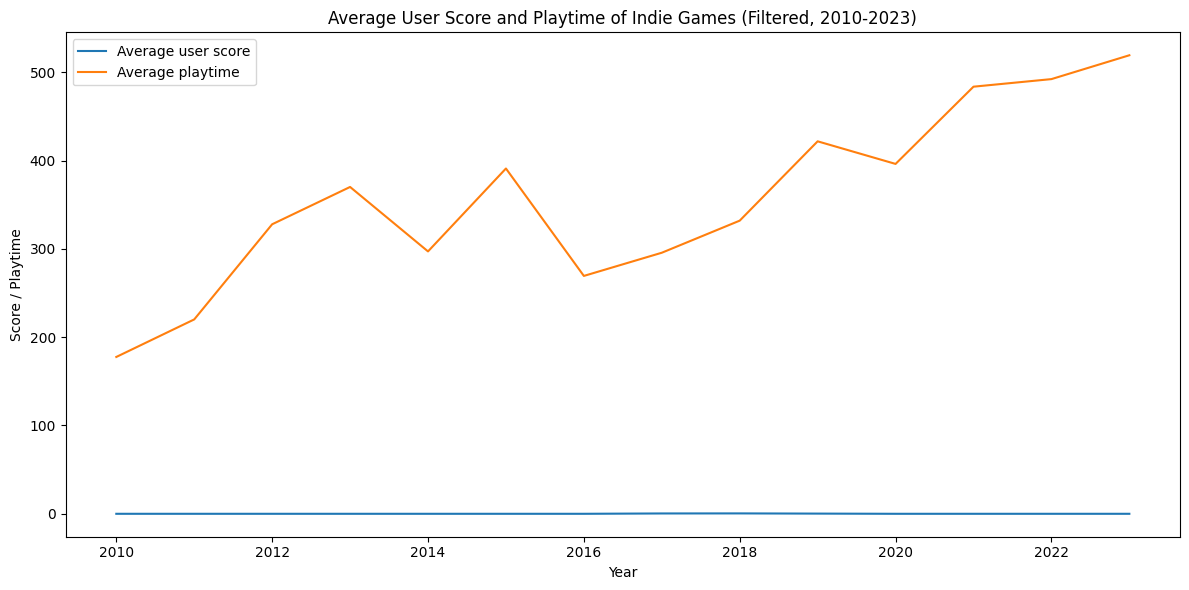

In [14]:
threshold = indie_filtered['average_playtime_forever'].quantile(0.99)
playtime_clean = indie_filtered[indie_filtered['average_playtime_forever'] < threshold].copy()

avg_playtime_by_year = playtime_clean.groupby('release_year')['average_playtime_forever'].mean()
avg_score_by_year = playtime_clean.groupby('release_year')['user_score'].mean()

plt.figure(figsize=(12, 6))
plt.plot(avg_score_by_year.index, avg_score_by_year, label='Average user score')
plt.plot(avg_playtime_by_year.index, avg_playtime_by_year, label='Average playtime')
plt.title('Average User Score and Playtime of Indie Games (Filtered, 2010-2023)')
plt.xlabel('Year')
plt.ylabel('Score / Playtime')
plt.legend()
plt.tight_layout()
plt.show()

## Genre word cloud

This view summarizes the most common genre labels associated with indie games.

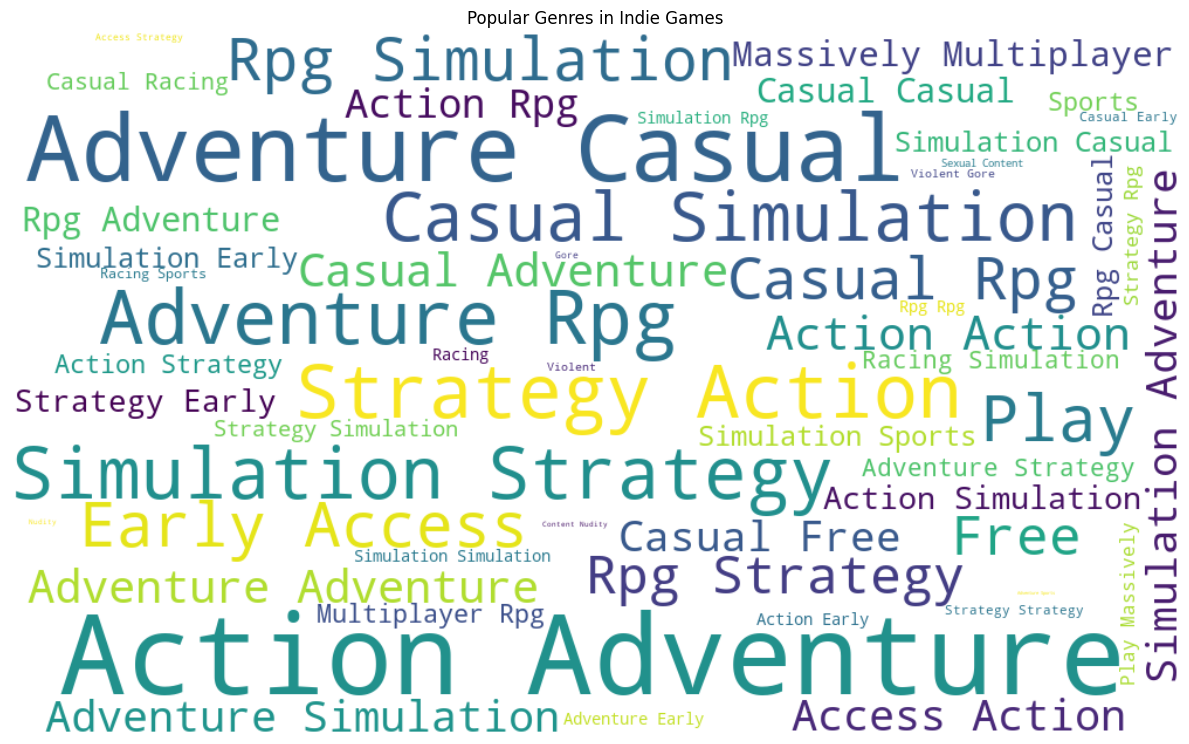

In [15]:
all_genres = [
    genre.strip().title()
    for sublist in df[df['is_indie']]['genres']
    for genre in sublist
    if genre.lower() != 'indie'
]

stopwords = {'Access', 'Play', 'Early', 'Free', 'Content'}
cleaned_genres = [g for g in all_genres if g not in stopwords]
genre_text = ' '.join(cleaned_genres)

wordcloud = WordCloud(width=1000, height=600, background_color='white', max_words=200).generate(genre_text)

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Popular Genres in Indie Games')
plt.tight_layout()
plt.show()

## Summary

Main takeaways:
- Indie releases grew sharply through the mid-2010s and then stabilized.
- Indie games appear to compete well on user scores while maintaining lower prices.
- Genre variety suggests that indie development succeeds through experimentation and niche appeal.
- Data preparation decisions matter: incomplete years and extreme outliers can distort the story.
